In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [2]:
words = open('../datasets/names.txt', 'r').read().splitlines()
len(words)
chars = sorted(set(list(''.join(words))))
print(chars)
stoi = {s : i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
print(stoi)

itos = {i: s for s,i in stoi.items()}
print(itos)
vocab_size = len(itos)
print(vocab_size)

['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [3]:
block_size = 3

def build_dataset(words):
    X,Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            iy = stoi[ch]
            X.append(context)
            Y.append(iy)
            context = context[1:] + [iy]
    X =torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, X.dtype, Y.shape, Y.dtype)
    return X,Y

random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
print(len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])



32033
torch.Size([182625, 3]) torch.int64 torch.Size([182625]) torch.int64
torch.Size([22655, 3]) torch.int64 torch.Size([22655]) torch.int64
torch.Size([22866, 3]) torch.int64 torch.Size([22866]) torch.int64


In [4]:
n_embd = 10
n_hidden = 200
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
# here we updating initial weights and biases to have lower starting stnd deviaton
# reason for that so less weights become saturated killing neurons
W1 = torch.randn([n_embd * block_size, n_hidden], generator=g) * (5/3) / ((n_embd * block_size) ** 0.5)
b1 = torch.randn(n_hidden, generator=g                       ) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g         ) * 0.01
b2 = torch.randn(vocab_size, generator=g                     ) * 0.0
parameters = [C, W1, b1, W2, b2]
print("total params:", sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


total params: 11897


In [5]:
max_steps = 200000
batch_size = 32
lossi = []
for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    h.retain_grad()
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f"{i:7d}/{max_steps:7d}: {loss.item():.4f}")
    lossi.append(loss.log10().item())
    # break
print(f"Final Loss: {loss.item():.4f}")



      0/ 200000: 3.3179
  10000/ 200000: 2.1910
  20000/ 200000: 2.3270
  30000/ 200000: 2.5396
  40000/ 200000: 1.9468
  50000/ 200000: 2.3331
  60000/ 200000: 2.3852
  70000/ 200000: 2.1173
  80000/ 200000: 2.3159
  90000/ 200000: 2.2010
 100000/ 200000: 1.8591
 110000/ 200000: 2.0881
 120000/ 200000: 1.9389
 130000/ 200000: 2.3913
 140000/ 200000: 2.0949
 150000/ 200000: 2.1458
 160000/ 200000: 1.7824
 170000/ 200000: 1.7249
 180000/ 200000: 1.9751
 190000/ 200000: 1.8614
Final Loss: 2.3840


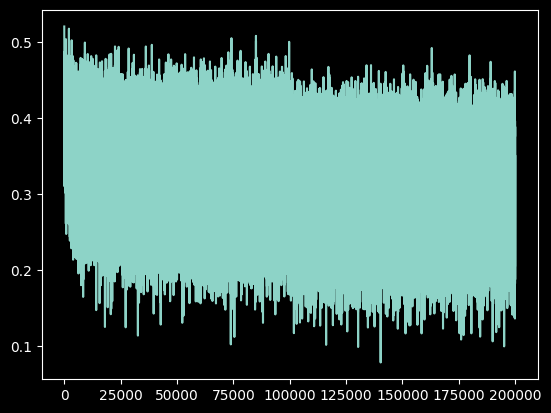

In [6]:
plt.plot(lossi)

(array([1059.,  229.,  163.,  142.,   95.,   83.,   67.,   63.,   57.,
          65.,   76.,   51.,   69.,   65.,   85.,   91.,   75.,   53.,
          62.,   76.,   70.,  100.,  117.,   91.,  110.,  125.,  104.,
          72.,  108.,   70.,   62.,   62.,   65.,   64.,   54.,   58.,
          65.,   62.,   53.,   53.,   53.,   66.,   67.,   81.,   93.,
         101.,  116.,  178.,  232., 1122.]),
 array([-1.  , -0.96, -0.92, -0.88, -0.84, -0.8 , -0.76, -0.72, -0.68,
        -0.64, -0.6 , -0.56, -0.52, -0.48, -0.44, -0.4 , -0.36, -0.32,
        -0.28, -0.24, -0.2 , -0.16, -0.12, -0.08, -0.04,  0.  ,  0.04,
         0.08,  0.12,  0.16,  0.2 ,  0.24,  0.28,  0.32,  0.36,  0.4 ,
         0.44,  0.48,  0.52,  0.56,  0.6 ,  0.64,  0.68,  0.72,  0.76,
         0.8 ,  0.84,  0.88,  0.92,  0.96,  1.  ]),
 <BarContainer object of 50 artists>)

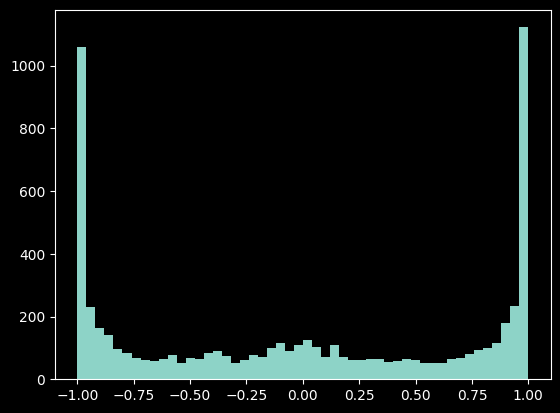

In [7]:
plt.hist(h.view(-1).tolist(), 50)

(array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   1.,
          0.,   3.,   2.,   3.,   3.,  14.,  19.,  55.,  72., 117., 196.,
        285., 343., 484., 710., 884., 862., 702., 533., 369., 288., 170.,
        109.,  77.,  48.,  26.,  10.,   6.,   2.,   1.,   1.,   0.,   0.,
          0.,   0.,   0.,   1.,   0.,   2.]),
 array([-5.11180647e-02, -4.92246492e-02, -4.73312338e-02, -4.54378183e-02,
        -4.35444029e-02, -4.16509874e-02, -3.97575720e-02, -3.78641565e-02,
        -3.59707411e-02, -3.40773256e-02, -3.21839102e-02, -3.02904947e-02,
        -2.83970793e-02, -2.65036638e-02, -2.46102484e-02, -2.27168329e-02,
        -2.08234175e-02, -1.89300020e-02, -1.70365866e-02, -1.51431711e-02,
        -1.32497557e-02, -1.13563402e-02, -9.46292475e-03, -7.56950930e-03,
        -5.67609385e-03, -3.78267840e-03, -1.88926294e-03,  4.15250659e-06,
         1.89756796e-03,  3.79098341e-03,  5.68439886e-03,  7.57781431e-03,
         9.47122976e-03,  1.13646452e-02,  1.32580

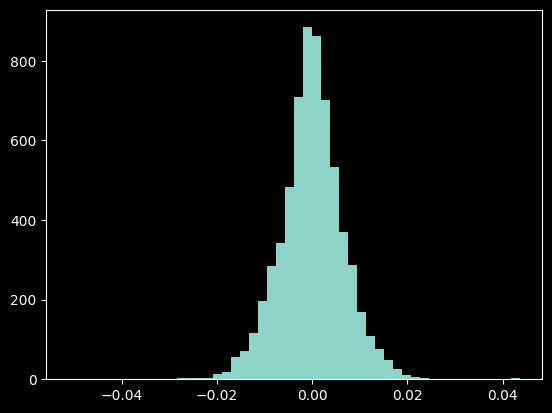

In [8]:
plt.hist(h.grad.view(-1).tolist(), 50)

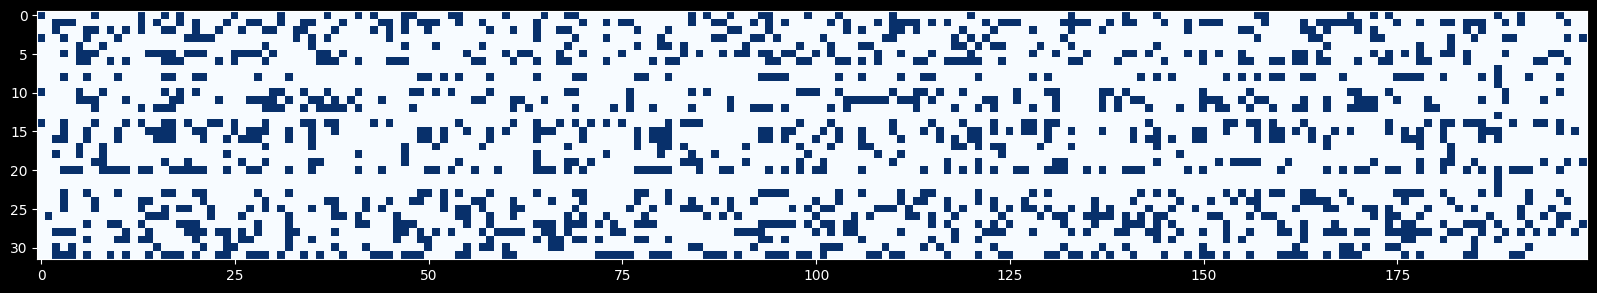

In [9]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='Blues', interpolation='nearest')

In [10]:
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train' : (Xtr, Ytr),
        'val' : (Xdev, Ydev),
        'test' : (Xte, Yte)
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    h = torch.tanh(embcat @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0376641750335693
val 2.106989622116089


orig values:
train 2.1267659664154053
val 2.1697638034820557